Parcial Juan Diego Chaparro Garcia 

In [1]:
import urllib.request
import tarfile
import os

# 🔹 Carpeta LOCAL descargar las imgs
os.makedirs("/content/stanford_dogs", exist_ok=True)

print("⬇️ Descargando imágenes...")
urllib.request.urlretrieve(
    "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar",
    "/content/stanford_dogs/images.tar"
)

print("📦 Extrayendo...")
with tarfile.open("/content/stanford_dogs/images.tar") as tar:
    tar.extractall(path="/content/stanford_dogs")

print("✅ Listo, imágenes en /content (LOCAL)")


⬇️ Descargando imágenes...
📦 Extrayendo...


/tmp/ipykernel_41548/3852929129.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="/content/stanford_dogs")


✅ Listo, imágenes en /content (LOCAL)


In [2]:
import urllib.request
import tarfile
import os

# 🔹 Carpeta local descaragar las coordenadas de cada perro en la img
base_path = "/content/stanford_dogs"
os.makedirs(base_path, exist_ok=True)

print("⬇️ Descargando anotaciones...")
url = "http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar"
urllib.request.urlretrieve(url, f"{base_path}/annotation.tar")

print("📦 Extrayendo anotaciones...")
with tarfile.open(f"{base_path}/annotation.tar") as tar:
    tar.extractall(path=base_path)

print("✅ Anotaciones listas en LOCAL")


⬇️ Descargando anotaciones...
📦 Extrayendo anotaciones...


/tmp/ipykernel_41548/1514713061.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=base_path)


✅ Anotaciones listas en LOCAL


In [ ]:
import os
#saber si se cargaron todas las imagenes necesarias
images_path = "/content/stanford_dogs/Images"

total = 0

for raza in os.listdir(images_path):
    raza_path = os.path.join(images_path, raza)
    
    if not os.path.isdir(raza_path):
        continue
    
    for img_file in os.listdir(raza_path):
        if img_file.endswith(".jpg"):
            total += 1

print(f"📊 Total de imágenes originales: {total}")


📊 Total de imágenes originales: 20580


In [4]:
import os
from PIL import Image
import xml.etree.ElementTree as ET

# 🔹 Rutas locales (NO Drive)
images_path     = "/content/stanford_dogs/Images"
annotation_path = "/content/stanford_dogs/Annotation"

output_path = "/content/processed_dogs"
os.makedirs(output_path, exist_ok=True)

contador = 0
limite = 30
#se evalua que el box find y el resize sea el correcto y se hace el ejemplo con 30 samples sin modificar los archivos originales
for raza in os.listdir(images_path):
    raza_img_path = os.path.join(images_path, raza)
    raza_ann_path = os.path.join(annotation_path, raza)

    if not os.path.isdir(raza_img_path):
        continue

    for img_file in os.listdir(raza_img_path):
        if contador >= limite:
            break

        if not img_file.endswith(".jpg"):
            continue

        img_path = os.path.join(raza_img_path, img_file)
        ann_path = os.path.join(raza_ann_path, img_file.replace(".jpg", ""))

        try:
            # Leer bounding box
            tree = ET.parse(ann_path)
            root = tree.getroot()
            obj  = root.find('object')
            bbox = obj.find('bndbox')

            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)

            # Procesar imagen
            img = Image.open(img_path).convert("RGB")

            # 🔥 Protección contra bbox inválido
            width, height = img.size
            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(width, xmax)
            ymax = min(height, ymax)

            if xmin >= xmax or ymin >= ymax:
                print(f"⚠️ BBOX inválido en {img_file}, se omite")
                continue

            img = img.crop((xmin, ymin, xmax, ymax))
            img = img.resize((100, 100))

            # Guardar copia local
            save_path = os.path.join(output_path, f"{contador}_{img_file}")
            img.save(save_path)

            contador += 1

        except Exception as e:
            print(f"⚠️ Error en {img_file}: {e}")

    if contador >= limite:
        break

print("✅ 30 imágenes procesadas y guardadas en /content/processed_dogs")


✅ 30 imágenes procesadas y guardadas en /content/processed_dogs


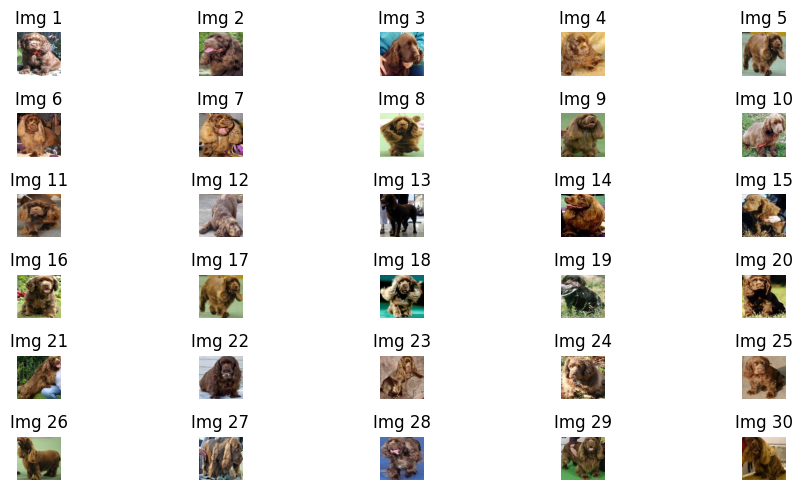

In [5]:
import matplotlib.pyplot as plt

processed_path = "/content/processed_dogs"
images = os.listdir(processed_path)

plt.figure(figsize=(10, 5))
#se muestra elñ resultado anterior
for i, img_name in enumerate(images):
    img_path = os.path.join(processed_path, img_name)
    img = Image.open(img_path)

    plt.subplot(6, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Img {i+1}")

plt.tight_layout()
plt.show()


In [6]:
import os
from PIL import Image
import xml.etree.ElementTree as ET
# se realiza el boxfind y el resize a las imagenes
# 🔹 Rutas locales
images_path     = "/content/stanford_dogs/Images"
annotation_path = "/content/stanford_dogs/Annotation"

# 🔹 Carpeta de salida local
output_path = "/content/stanford_dogs_processed"
os.makedirs(output_path, exist_ok=True)

for raza in os.listdir(images_path):
    raza_img_path = os.path.join(images_path, raza)
    raza_ann_path = os.path.join(annotation_path, raza)

    if not os.path.isdir(raza_img_path):
        continue

    # 🔹 Crear carpeta por raza
    raza_output_path = os.path.join(output_path, raza)
    os.makedirs(raza_output_path, exist_ok=True)

    for img_file in os.listdir(raza_img_path):
        if not img_file.endswith(".jpg"):
            continue

        img_path = os.path.join(raza_img_path, img_file)
        ann_path = os.path.join(raza_ann_path, img_file.replace(".jpg", ""))

        try:
            # Leer bounding box
            tree = ET.parse(ann_path)
            root = tree.getroot()
            obj  = root.find('object')
            bbox = obj.find('bndbox')

            xmin = int(bbox.find('xmin').text)
            ymin = int(bbox.find('ymin').text)
            xmax = int(bbox.find('xmax').text)
            ymax = int(bbox.find('ymax').text)

            # Procesar imagen
            img = Image.open(img_path).convert("RGB")

            # 🔥 Validación para evitar imágenes negras
            width, height = img.size
            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(width, xmax)
            ymax = min(height, ymax)

            if xmin >= xmax or ymin >= ymax:
                print(f"⚠️ BBOX inválido en {img_file}, se omite")
                continue

            img = img.crop((xmin, ymin, xmax, ymax))
            img = img.resize((100, 100))

            # Guardar en carpeta local
            save_path = os.path.join(raza_output_path, img_file)
            img.save(save_path)

        except Exception as e:
            print(f"⚠️ Error en {img_file}: {e}")

print("✅ Imágenes guardadas en /content/stanford_dogs_processed")


✅ Imágenes guardadas en /content/stanford_dogs_processed


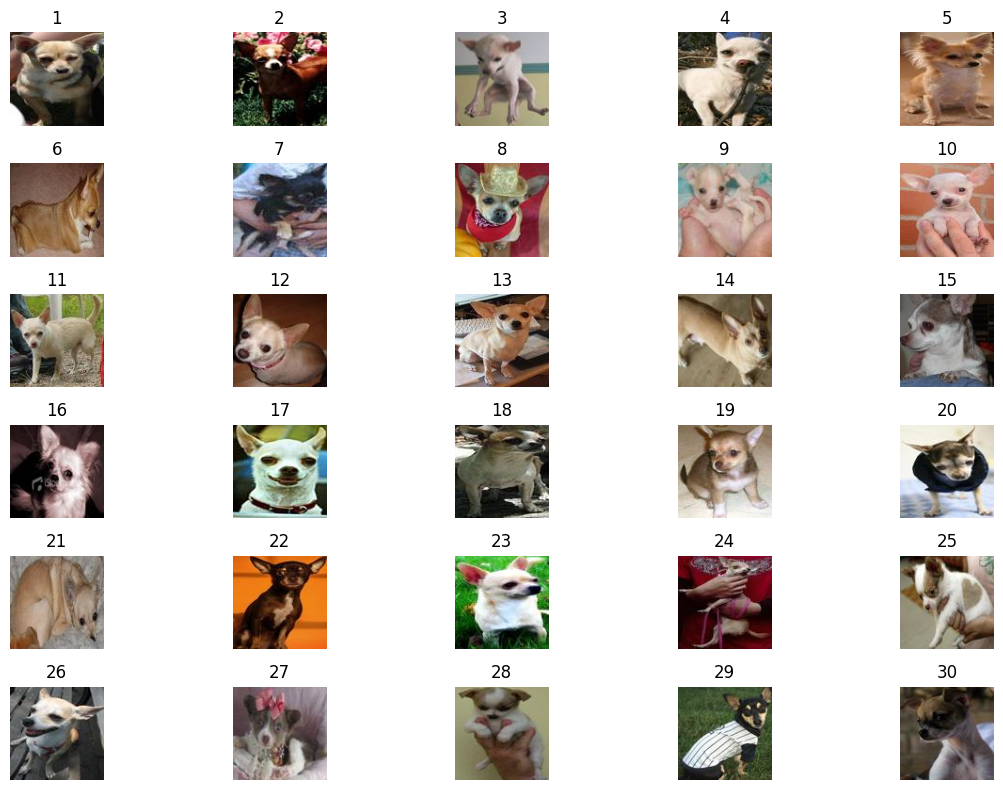

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image

processed_path = "/content/stanford_dogs_processed"
# se ve si se hizo correctamente el paso anterior
# 🔹 Obtener todas las imágenes dentro de subcarpetas (por raza)
all_images = []

for raza in os.listdir(processed_path):
    raza_path = os.path.join(processed_path, raza)
    
    if not os.path.isdir(raza_path):
        continue
    
    for img_name in os.listdir(raza_path):
        if img_name.endswith(".jpg"):
            all_images.append(os.path.join(raza_path, img_name))

# 🔹 Ordenar y tomar primeras 30
all_images = sorted(all_images)[:30]

# 🔹 Mostrar
plt.figure(figsize=(12, 8))

for i, img_path in enumerate(all_images):
    img = Image.open(img_path)
    
    plt.subplot(6, 5, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{i+1}")

plt.tight_layout()
plt.show()


In [8]:
#se evalua si se realizo con el num total de imgs
import os

processed_path = "/content/stanford_dogs_processed"

total = 0

for raza in os.listdir(processed_path):
    raza_path = os.path.join(processed_path, raza)
    
    if not os.path.isdir(raza_path):
        continue
    
    for img_file in os.listdir(raza_path):
        if img_file.endswith(".jpg"):
            total += 1

print(f"📊 Total de imágenes procesadas: {total}")


📊 Total de imágenes procesadas: 20580


In [2]:
import os
from PIL import Image
#se verifica el tamaño de las imagenes
processed_path = "/content/stanford_dogs_processed"

imagenes = []

# 🔹 Recorrer subcarpetas
for raza in os.listdir(processed_path):
    raza_path = os.path.join(processed_path, raza)
    
    if not os.path.isdir(raza_path):
        continue
    
    for img_name in os.listdir(raza_path):
        if img_name.endswith(".jpg"):
            imagenes.append(os.path.join(raza_path, img_name))

# 🔹 Tomar primeras 10
imagenes = sorted(imagenes)[:10]

# 🔹 Mostrar tamaños
for i, img_path in enumerate(imagenes):
    img = Image.open(img_path)
    print(f"Imagen {i+1}: {img.size}")  # (ancho, alto)


Imagen 1: (100, 100)
Imagen 2: (100, 100)
Imagen 3: (100, 100)
Imagen 4: (100, 100)
Imagen 5: (100, 100)
Imagen 6: (100, 100)
Imagen 7: (100, 100)
Imagen 8: (100, 100)
Imagen 9: (100, 100)
Imagen 10: (100, 100)


In [ ]:
import tensorflow as tf

data_dir = "/content/stanford_dogs_processed"
# se hacen batches para que la memoria no reviente con el total de imagenes
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(100, 100),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(100, 100),
    batch_size=32
)


Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
#se divide en datos y etiiquetas e entrenamiento y prueba
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization_layer(x), y))


In [ ]:
#verificar la normlizacion
for images, labels in train_ds.take(1):  # toma 1 batch
    print("Valores originales:")
    print("min:", images.numpy().min(), "max:", images.numpy().max())

In [4]:
import numpy as np
#veo que las clases tienen solo el numero y no el nombre y el numero de clases es 120


labels_all = []

for images, labels in train_ds:
    labels_all.extend(labels.numpy())

unique_labels = np.unique(labels_all)

print("Etiquetas únicas:", unique_labels)
print("Número de clases:", len(unique_labels))



Etiquetas únicas: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]
Número de clases: 120


In [9]:
import os
#ver el nombre de las razas
images_path = "/content/stanford_dogs/Images"
clases = [raza.split("-")[1] for raza in sorted(os.listdir(images_path)) if "-" in raza]
print(clases)

['Chihuahua', 'Japanese_spaniel', 'Maltese_dog', 'Pekinese', 'Shih', 'Blenheim_spaniel', 'papillon', 'toy_terrier', 'Rhodesian_ridgeback', 'Afghan_hound', 'basset', 'beagle', 'bloodhound', 'bluetick', 'black', 'Walker_hound', 'English_foxhound', 'redbone', 'borzoi', 'Irish_wolfhound', 'Italian_greyhound', 'whippet', 'Ibizan_hound', 'Norwegian_elkhound', 'otterhound', 'Saluki', 'Scottish_deerhound', 'Weimaraner', 'Staffordshire_bullterrier', 'American_Staffordshire_terrier', 'Bedlington_terrier', 'Border_terrier', 'Kerry_blue_terrier', 'Irish_terrier', 'Norfolk_terrier', 'Norwich_terrier', 'Yorkshire_terrier', 'wire', 'Lakeland_terrier', 'Sealyham_terrier', 'Airedale', 'cairn', 'Australian_terrier', 'Dandie_Dinmont', 'Boston_bull', 'miniature_schnauzer', 'giant_schnauzer', 'standard_schnauzer', 'Scotch_terrier', 'Tibetan_terrier', 'silky_terrier', 'soft', 'West_Highland_white_terrier', 'Lhasa', 'flat', 'curly', 'golden_retriever', 'Labrador_retriever', 'Chesapeake_Bay_retriever', 'Germa

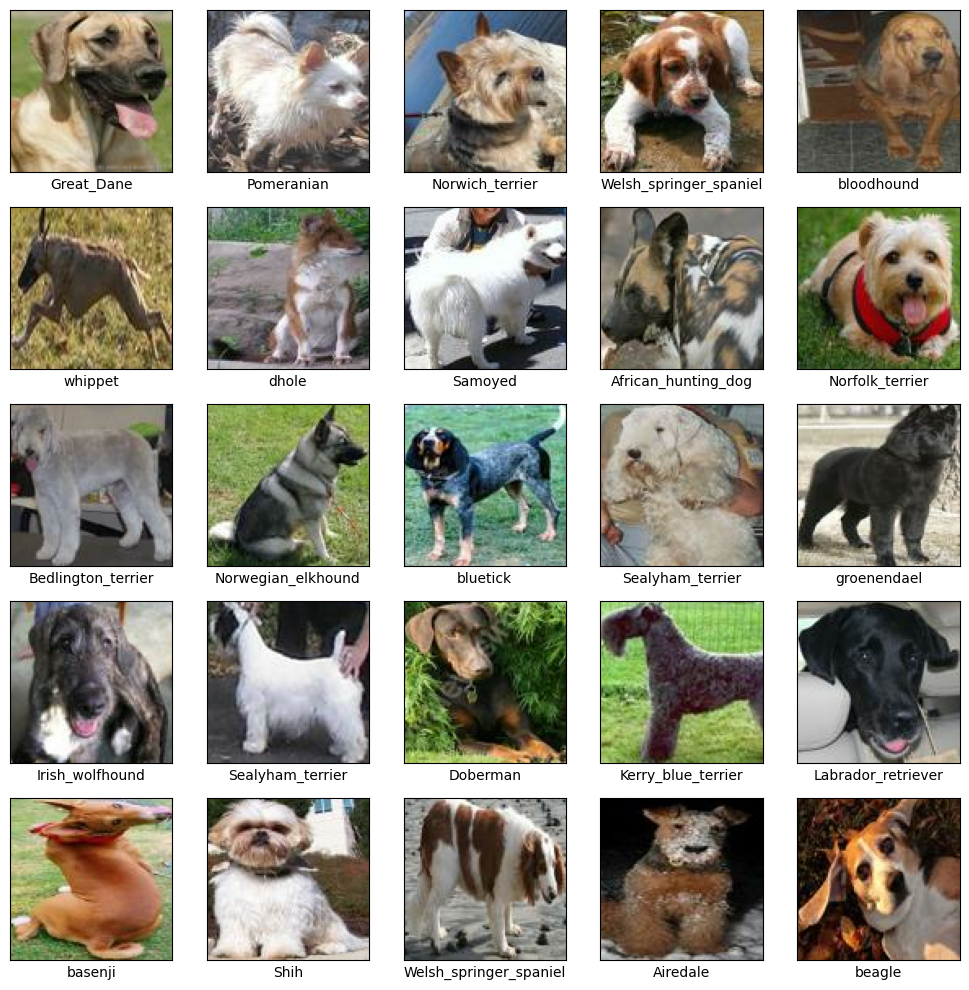

In [13]:
import matplotlib.pyplot as plt
#se observan las primeras 25 imagenes de entrenamiento con sus etiquetas correspondinetes




for images, labels in train_ds.take(1):
    
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))

    for i in range(25):
        row = i // 5
        col = i % 5
        
        img = (images[i].numpy() * 255).astype("uint8")  # 🔥 corregido
        
        axes[row, col].imshow(img)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        axes[row, col].set_xlabel(clases[labels[i]], ha='center')

    plt.tight_layout()
    plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
#se agrega data argumentation para mejorar el modelo
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),  # reduce un poco la rotación
    layers.RandomZoom(0.05),      # reduce el zoom
    layers.RandomContrast(0.1),
    layers.Lambda(lambda x: tf.clip_by_value(x, 0.0, 1.0))  # asegura valores en rango válido
])

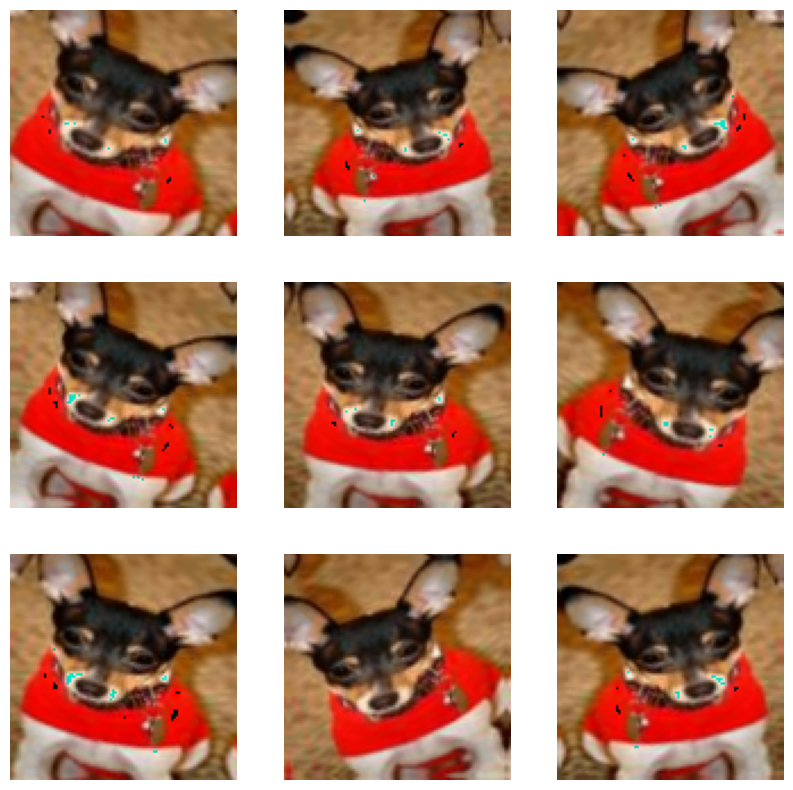

In [ ]:
import matplotlib.pyplot as plt
#se grafica


plt.figure(figsize=(10, 10))

# Tomar una imagen del dataset
for images, labels in train_ds.take(1):
    img = images[0]  # una sola imagen

    for i in range(9):
        augmented = data_augmentation(tf.expand_dims(img, 0))  # 🔥 añadir batch
        
        plt.subplot(3, 3, i+1)
        plt.imshow((augmented[0].numpy() * 255).astype("uint8"))  # 🔥 corregir rango
        plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras import layers
from tensorflow import keras

#modelo que recibe img 100,100,3 con 2 capas ocultas de 64 y 32 y ademas 2 kernel 3x3 de 64 y 32 tambien
#2 convolusiones y luego el aplanamiento

model = keras.Sequential([
    keras.Input(shape=(100, 100, 3)),

    # Aumentación de datos
    data_augmentation,  

    # Convoluciones iniciales
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Aplanamiento
    layers.Flatten(),

    # Capas densas para combinar características
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    # Capa de salida: número de clases dinámico
    layers.Dense(len(clases), activation='softmax')
])

# Ver resumen de arquitectura y parámetros
model.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# 🔧 Compilación del modelo
model.compile(
    optimizer='adam',  # Optimizador que ajusta los pesos automáticamente
    loss='sparse_categorical_crossentropy',  # Función de pérdida para clasificación multiclase con etiquetas enteras
    metrics=['accuracy']  # Métrica para evaluar el rendimiento
)

# 🛑 Callback: detiene el entrenamiento si no hay mejora
early_stopping = EarlyStopping(
    monitor='val_loss',          # Observa el error en el conjunto de validación
    patience=5,                 # Espera 5 épocas sin mejora antes de detener
    restore_best_weights=True   # Recupera los mejores pesos encontrados
)

# 🚀 Entrenamiento del modelo
history = model.fit(
    train_ds,               # Dataset de entrenamiento (ya incluye imágenes y etiquetas)
    validation_data=val_ds, # Dataset de validación
    epochs=50,              # Número máximo de épocas
    callbacks=[early_stopping]  # Lista de callbacks (en este caso solo EarlyStopping)
)

Epoch 1/40
515/515 ━━━━━━━━━━━━━━━━━━━━ 357s 689ms/step - accuracy: 0.0137 - loss: 4.7582 - val_accuracy: 0.0211 - val_loss: 4.6593
Epoch 2/40
515/515 ━━━━━━━━━━━━━━━━━━━━ 350s 680ms/step - accuracy: 0.0238 - loss: 4.5609 - val_accuracy: 0.0301 - val_loss: 4.4609
Epoch 3/40
515/515 ━━━━━━━━━━━━━━━━━━━━ 348s 677ms/step - accuracy: 0.0306 - loss: 4.4397 - val_accuracy: 0.0379 - val_loss: 4.3485
Epoch 4/40
515/515 ━━━━━━━━━━━━━━━━━━━━ 361s 700ms/step - accuracy: 0.0392 - loss: 4.3321 - val_accuracy: 0.0435 - val_loss: 4.2529
Epoch 5/40
515/515 ━━━━━━━━━━━━━━━━━━━━ 352s 684ms/step - accuracy: 0.0449 - loss: 4.2612 - val_accuracy: 0.0513 - val_loss: 4.2073
Epoch 6/40
515/515 ━━━━━━━━━━━━━━━━━━━━ 352s 684ms/step - accuracy: 0.0490 - loss: 4.2058 - val_accuracy: 0.0571 - val_loss: 4.1412
Epoch 7/40
515/515 ━━━━━━━━━━━━━━━━━━━━ 350s 679ms/step - accuracy: 0.0573 - loss: 4.1606 - val_accuracy: 0.0688 - val_loss: 4.0974
Epoch 8/40
515/515 ━━━━━━━━━━━━━━━━━━━━ 382s 680ms/step - accuracy: 0.0636 -

In [27]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

NameError: name 'history' is not defined

In [ ]:
model.save('modelo_perros.keras')
print("✅ Modelo guardado")